# Validações Estatísticas do BeamNG como Digital Twin — v2

Correções aplicadas:
- GPS (lat/lon) → coordenadas locais em metros via Haversine
- `throttle` real: separador `, ` com espaço → `skipinitialspace=True`
- `vel` simulado: lista string → norma euclidiana (velocidade escalar)
- `ime` simulado: coluna com encoding corrompido → renomeada para `time`
- Tempo simulado: Unix timestamp → segundos relativos
- Normalização: MinMaxScaler por fonte, por coluna
- Alinhamento: corte na duração mínima + `join='inner'`

## 1. Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import correlate
from sklearn.preprocessing import MinMaxScaler
from os import listdir
import ast

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 2. Funções auxiliares

In [12]:
# Haversine: converte lat/lon (graus) -> X/Y em metros 
# Usa o primeiro ponto como origem (0, 0)
def latlon_para_metros(lat, lon):
    """
    Converte arrays de latitude/longitude (graus decimais) para
    deslocamento em metros a partir do primeiro ponto.
    Retorna (x_metros, y_metros).
    """
    R = 6_371_000.0  # raio médio da Terra em metros
    lat0, lon0 = np.radians(lat[0]), np.radians(lon[0])
    lat_r = np.radians(lat)
    lon_r = np.radians(lon)
    x = R * (lon_r - lon0) * np.cos(lat0)   # Leste-Oeste
    y = R * (lat_r - lat0)                   # Norte-Sul
    return x, y


# Parser de coluna 'vel' do simulado 
def parse_vel(s):
    """Converte string '[vx, vy, vz]' → norma euclidiana (velocidade escalar)."""
    try:
        v = ast.literal_eval(str(s))
        return float(np.linalg.norm(v))
    except Exception:
        return np.nan

## 3. Carregar dados

In [ ]:
# REAL 
# skipinitialspace=True remove espaços após vírgulas no header
reais = []
for file in sorted(listdir('circuito4/real')):
    reais.append(pd.read_csv(
        f'circuito4/real/1.csv',
        sep=',',
        skipinitialspace=True
    ))
print(f"Reais carregados: {len(reais)}")

# SIMULADO 
simulados = []
for file in sorted(listdir('circuito4/simulado1')):
    simulados.append(pd.read_csv(
        f'circuito4/simulado1/readable.csv',
        sep=';'
    ))
print(f"Simulados carregados: {len(simulados)}")

Reais carregados: 10
Simulados carregados: 3


## 4. Preparação — REAL

In [14]:
def preparar_real(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Tempo: já são segundos relativos (0.000, 0.983, ...)
    df = df.sort_values('Time (sec)').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['Time (sec)'], unit='s')
    df = df.set_index('time')
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(axis=1, how='all')

    # Converter GPS -> metros locais 
    # Reatribui posX/posY como deslocamento em metros a partir do ponto inicial
    lat = df['Latitude (deg)'].values
    lon = df['Longitude (deg)'].values
    x_m, y_m = latlon_para_metros(lat, lon)
    df['posX'] = x_m
    df['posY'] = y_m
    df['posZ'] = df['Altitude (m)'].values

    #  Throttle 
    df = df.rename(columns={
        'Posição D do pedal do acelerador (%)': 'throttle'
    })

    # Velocidade (GPS) 
    if 'Velocidade do GPS (km/h)' in df.columns:
        df['vel'] = df['Velocidade do GPS (km/h)'] / 3.6   # km/h → m/s

    # Reamostrar e interpolar
    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df


real = preparar_real(reais[0])
print(f"Real → {len(real)} amostras | duração: {real.index[-1]}")
print(f"Colunas disponíveis (amostra): {[c for c in real.columns if c in ['throttle','posX','posY','posZ','vel']]}")

Real → 4430 amostras | duração: 0 days 00:07:22.900000
Colunas disponíveis (amostra): ['throttle', 'posX', 'posY', 'posZ', 'vel']


## 5. Preparação — SIMULADO

In [15]:
def preparar_simulado(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Corrigir coluna de tempo com encoding corrompido ('ime' em vez de 'time')
    # A primeira coluna sempre é o timestamp Unix
    time_col = df.columns[0]
    df = df.rename(columns={time_col: 'time'})

    # Tempo: Unix timestamp -> segundos relativos
    df = df.sort_values('time').reset_index(drop=True)
    df['time'] = df['time'] - df['time'].iloc[0]          # zera na origem
    df['time'] = pd.to_timedelta(df['time'], unit='s')
    df = df.set_index('time')

    # Velocidade: lista string -> norma euclidiana
    if 'vel' in df.columns:
        df['vel'] = df['vel'].apply(parse_vel)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(axis=1, how='all')
    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df


simulado = preparar_simulado(simulados[0])
print(f"Simulado -> {len(simulado)} amostras | duração: {simulado.index[-1]}")
print(f"Colunas disponíveis (amostra): {[c for c in simulado.columns if c in ['throttle','posX','posY','posZ','vel']]}")

Simulado -> 2853 amostras | duração: 0 days 00:04:45.200000
Colunas disponíveis (amostra): ['posX', 'posY', 'posZ', 'throttle', 'vel']


## 6. Inspecionar posição — verificar escala pós-conversão

In [16]:
# PosX/posY do real agora devem estar em metros (valores pequenos)
print("REAL — estatísticas de posição (em metros):")
print(real[['posX','posY','posZ']].describe().round(2))

print("\nSIMULADO — estatísticas de posição (em metros):")
print(simulado[['posX','posY','posZ']].describe().round(2))

print("\nREAL — throttle:")
print(real['throttle'].describe().round(3))

print("\nSIMULADO — throttle:")
print(simulado['throttle'].describe().round(3))

REAL — estatísticas de posição (em metros):
          posX     posY     posZ
count  4430.00  4430.00  4430.00
mean    -78.82  -163.11    22.86
std     230.31   349.68     1.47
min    -433.55  -897.79    19.76
25%    -286.23  -434.08    21.58
50%     -66.68   -57.90    22.94
75%     110.42    67.30    24.23
max     369.80   374.50    25.46

SIMULADO — estatísticas de posição (em metros):
          posX     posY     posZ
count  2853.00  2853.00  2853.00
mean     34.16    80.55    26.73
std     245.74   381.44     2.66
min    -337.18  -658.91    22.67
25%    -213.21  -250.61    24.64
50%      32.96   193.54    26.52
75%     249.81   341.10    27.80
max     471.33   622.82    33.11

REAL — throttle:
count    4430.000
mean       21.346
std         3.692
min         0.000
25%        19.294
50%        22.314
75%        23.608
max        29.020
Name: throttle, dtype: float64

SIMULADO — throttle:
count    2853.000
mean        0.219
std         0.337
min         0.000
25%         0.000
50%     

## 7. Selecionar colunas comparáveis e cortar duração mínima

In [17]:
colunas = ['throttle', 'posX', 'posY', 'posZ']

# Adicionar vel se disponível em ambos
if 'vel' in real.columns and 'vel' in simulado.columns:
    colunas.append('vel')
    print("✓ velocidade incluída na análise")

# Verificar disponibilidade
for col in colunas:
    ok_r = col in real.columns
    ok_s = col in simulado.columns
    print(f"{'✓' if (ok_r and ok_s) else '✗'} {col:10s}  real={'OK' if ok_r else 'FALTA':6s}  simulado={'OK' if ok_s else 'FALTA'}")

# Corte na duração mínima
duracao_min = min(real.index[-1], simulado.index[-1])
real     = real.loc[:duracao_min, colunas]
simulado = simulado.loc[:duracao_min, colunas]

print(f"\nDuração comum: {duracao_min}")
print(f"Amostras — real: {len(real)} | simulado: {len(simulado)}")

✓ velocidade incluída na análise
✓ throttle    real=OK      simulado=OK
✓ posX        real=OK      simulado=OK
✓ posY        real=OK      simulado=OK
✓ posZ        real=OK      simulado=OK
✓ vel         real=OK      simulado=OK

Duração comum: 0 days 00:04:45.200000
Amostras — real: 2853 | simulado: 2853


## 8. Normalização MinMaxScaler (por fonte, por coluna)

In [18]:
def normalizar_minmax(df, cols):
    scaler = MinMaxScaler()
    arr = scaler.fit_transform(df[cols])
    return pd.DataFrame(arr, index=df.index, columns=cols)

real_norm = normalizar_minmax(real, colunas)
sim_norm  = normalizar_minmax(simulado, colunas)

# Juntar com join='inner' para alinhamento perfeito
df = pd.concat(
    [real_norm.add_prefix('real_'), sim_norm.add_prefix('sim_')],
    axis=1, join='inner'
).dropna()

print(f"Shape final: {df.shape} | NaNs: {df.isna().sum().sum()}")
df.head(3)

Shape final: (2853, 10) | NaNs: 0


,real_throttle,real_posX,real_posY,real_posZ,real_vel,sim_throttle,sim_posX,sim_posY,sim_posZ,sim_vel
time,,,,,,,,,,
0 days 00:00:00,0.0,0.718031,0.881152,0.0,0.040448,0.013371,0.554338,0.705495,0.068615,0.003539
0 days 00:00:00.100000,0.0,0.717955,0.881128,0.0,0.035953,0.033375,0.554322,0.705497,0.067710,0.005670
0 days 00:00:00.200000,0.0,0.717880,0.881104,0.0,0.031459,0.055034,0.554292,0.705499,0.067033,0.008225


## 9. Plot das séries normalizadas

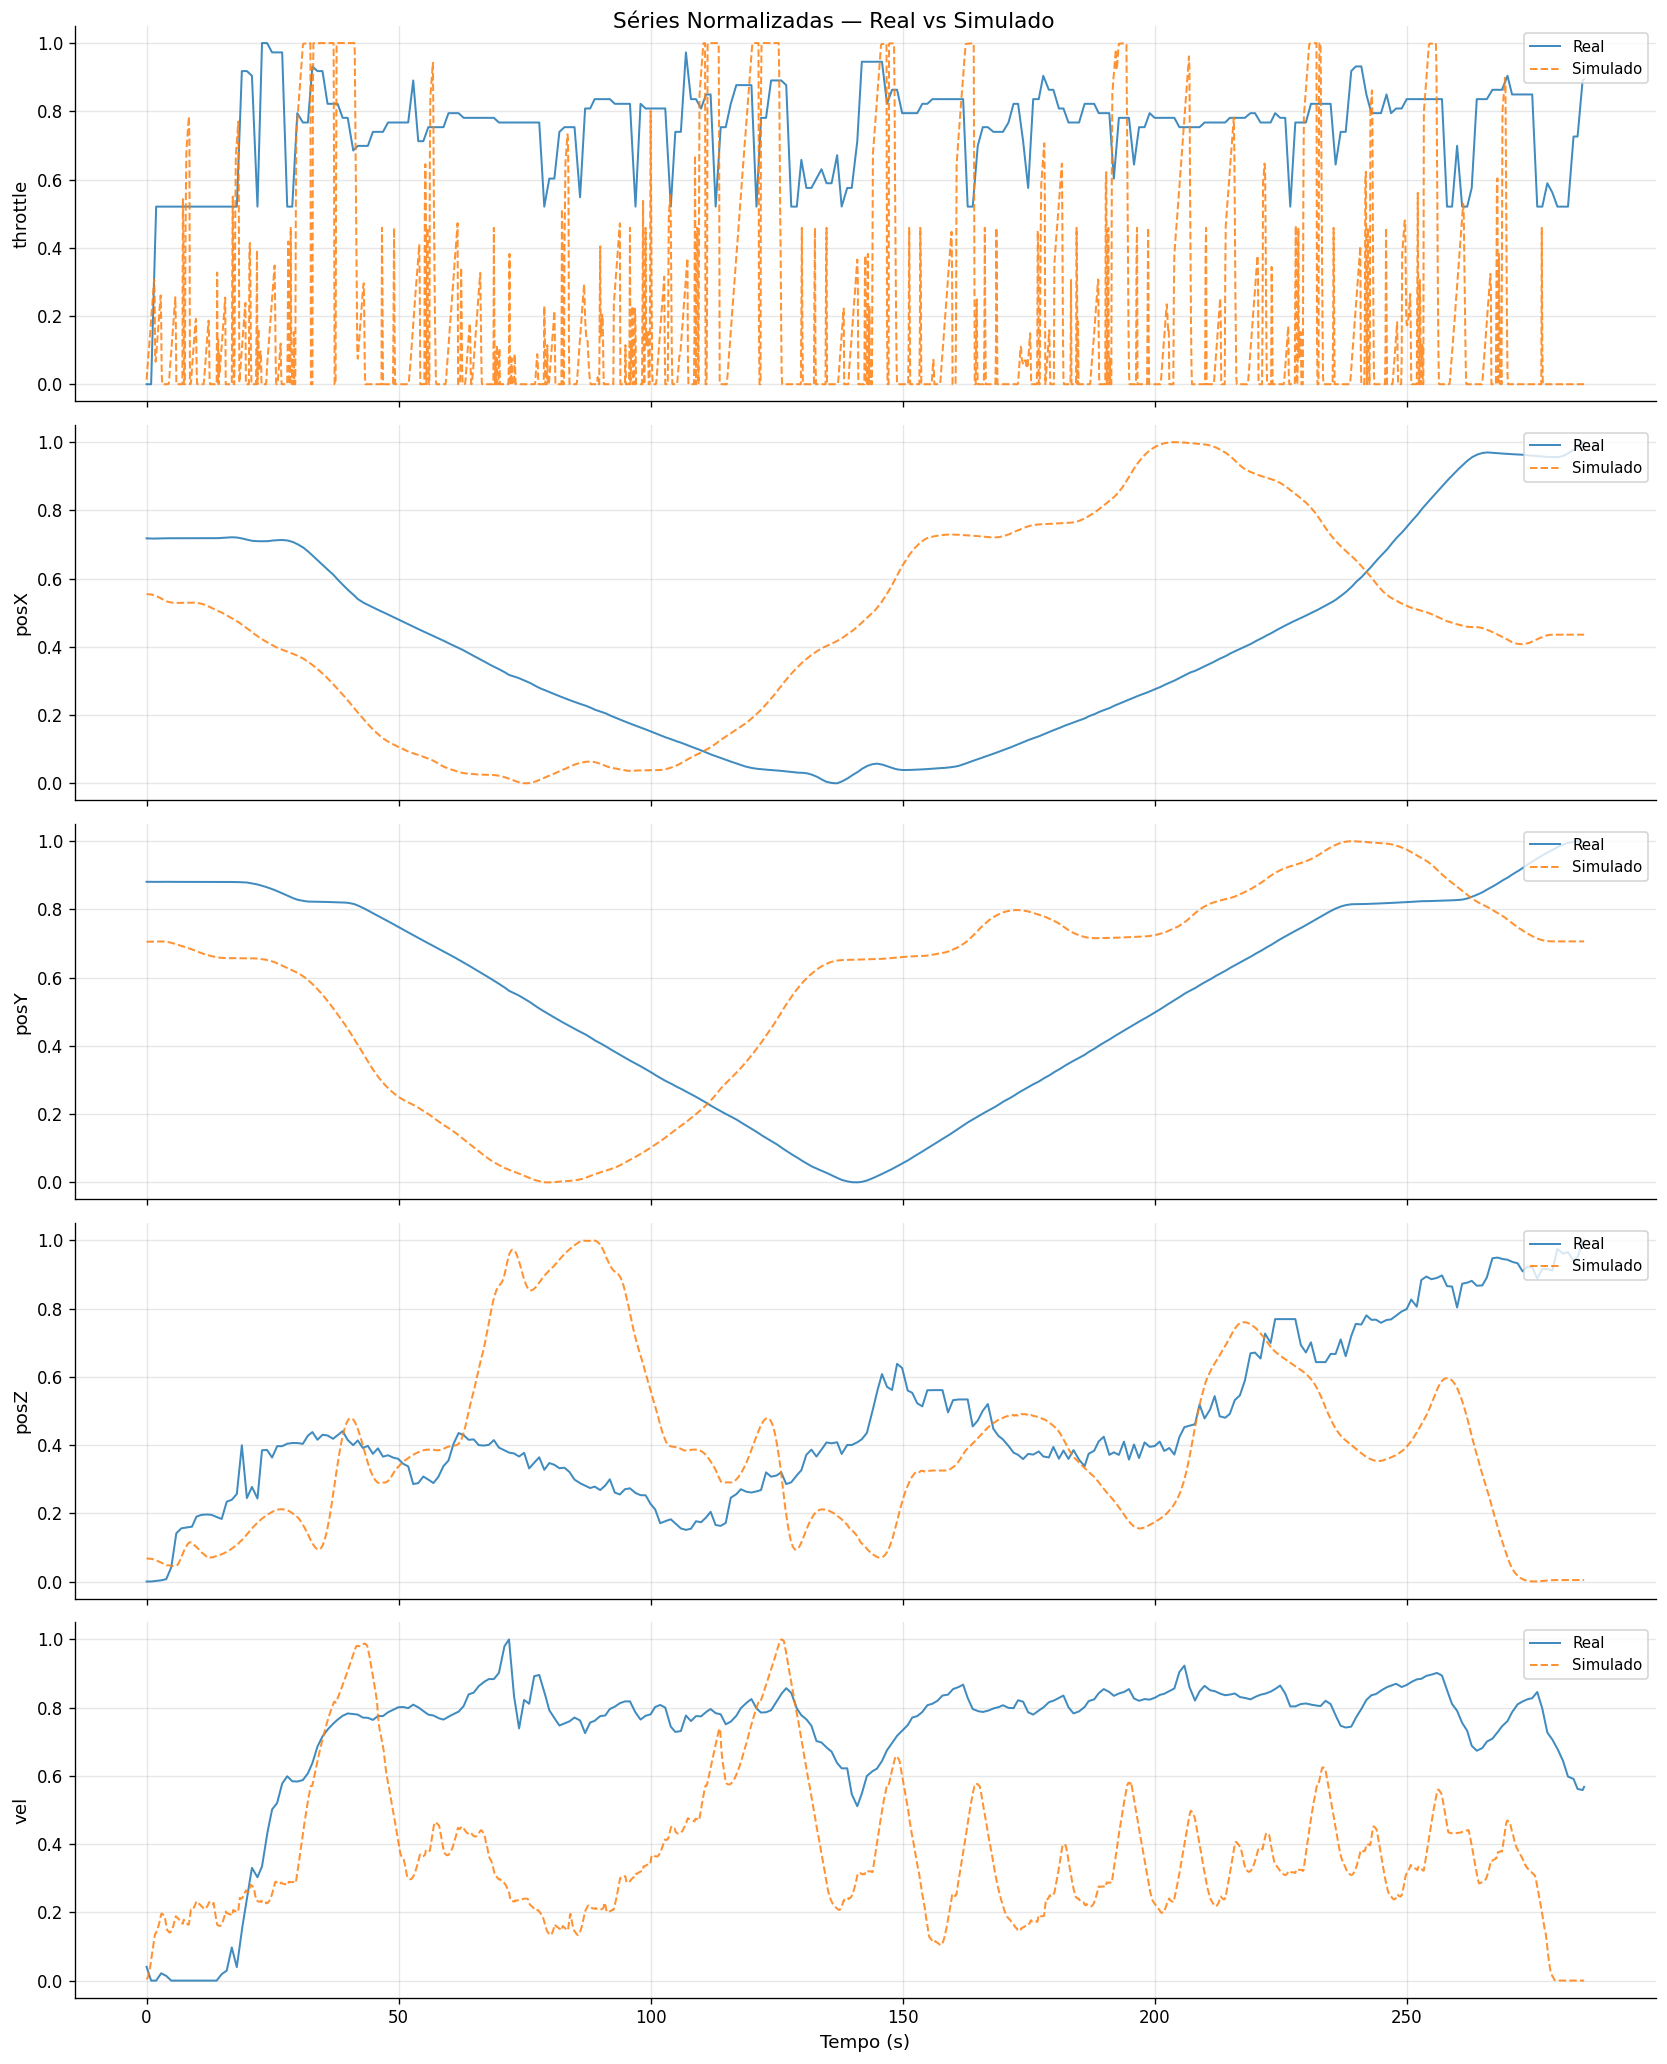

In [19]:
t = df.index.total_seconds()

fig, axes = plt.subplots(len(colunas), 1, figsize=(14, 3.5 * len(colunas)), sharex=True)
if len(colunas) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas):
    ax.plot(t, df[f'real_{col}'], label='Real',      color='#1f77b4', lw=1.2, alpha=0.85)
    ax.plot(t, df[f'sim_{col}'],  label='Simulado',  color='#ff7f0e', lw=1.2, alpha=0.85, ls='--')
    ax.set_ylabel(col, fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(-0.05, 1.05)

axes[-1].set_xlabel('Tempo (s)', fontsize=11)
fig.suptitle('Séries Normalizadas — Real vs Simulado', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Trajetória espacial (posX × posY)

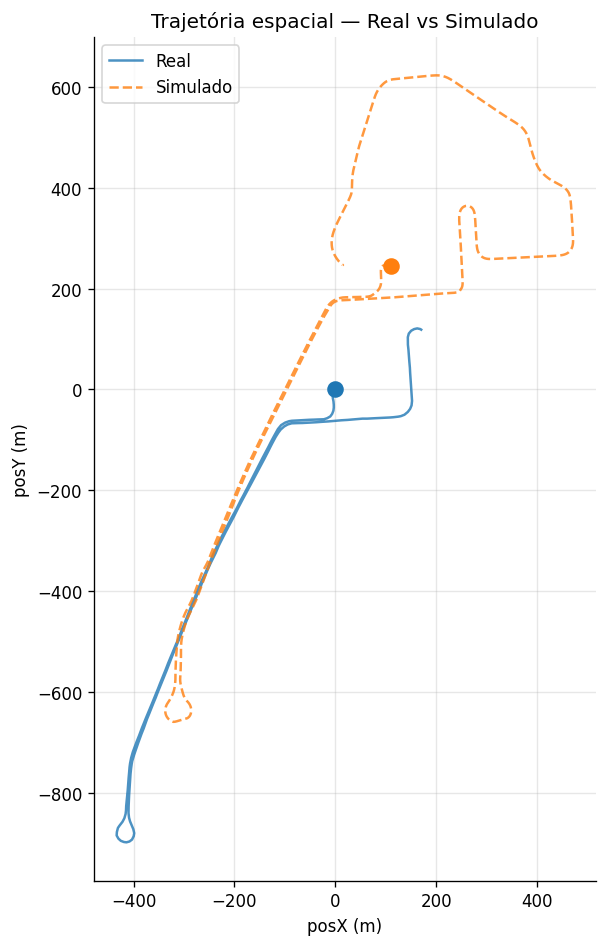

In [20]:
# Plot em escala original (metros) para verificar se o circuito faz sentido
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(real['posX'],     real['posY'],     label='Real',     color='#1f77b4', lw=1.5, alpha=0.8)
ax.plot(simulado['posX'], simulado['posY'], label='Simulado', color='#ff7f0e', lw=1.5, alpha=0.8, ls='--')
ax.scatter(*[real['posX'].iloc[0],     real['posY'].iloc[0]],     color='#1f77b4', s=80, zorder=5, marker='o')
ax.scatter(*[simulado['posX'].iloc[0], simulado['posY'].iloc[0]], color='#ff7f0e', s=80, zorder=5, marker='o')
ax.set_xlabel('posX (m)')
ax.set_ylabel('posY (m)')
ax.set_title('Trajetória espacial — Real vs Simulado')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 11. Detecção de LAG por cross-correlação

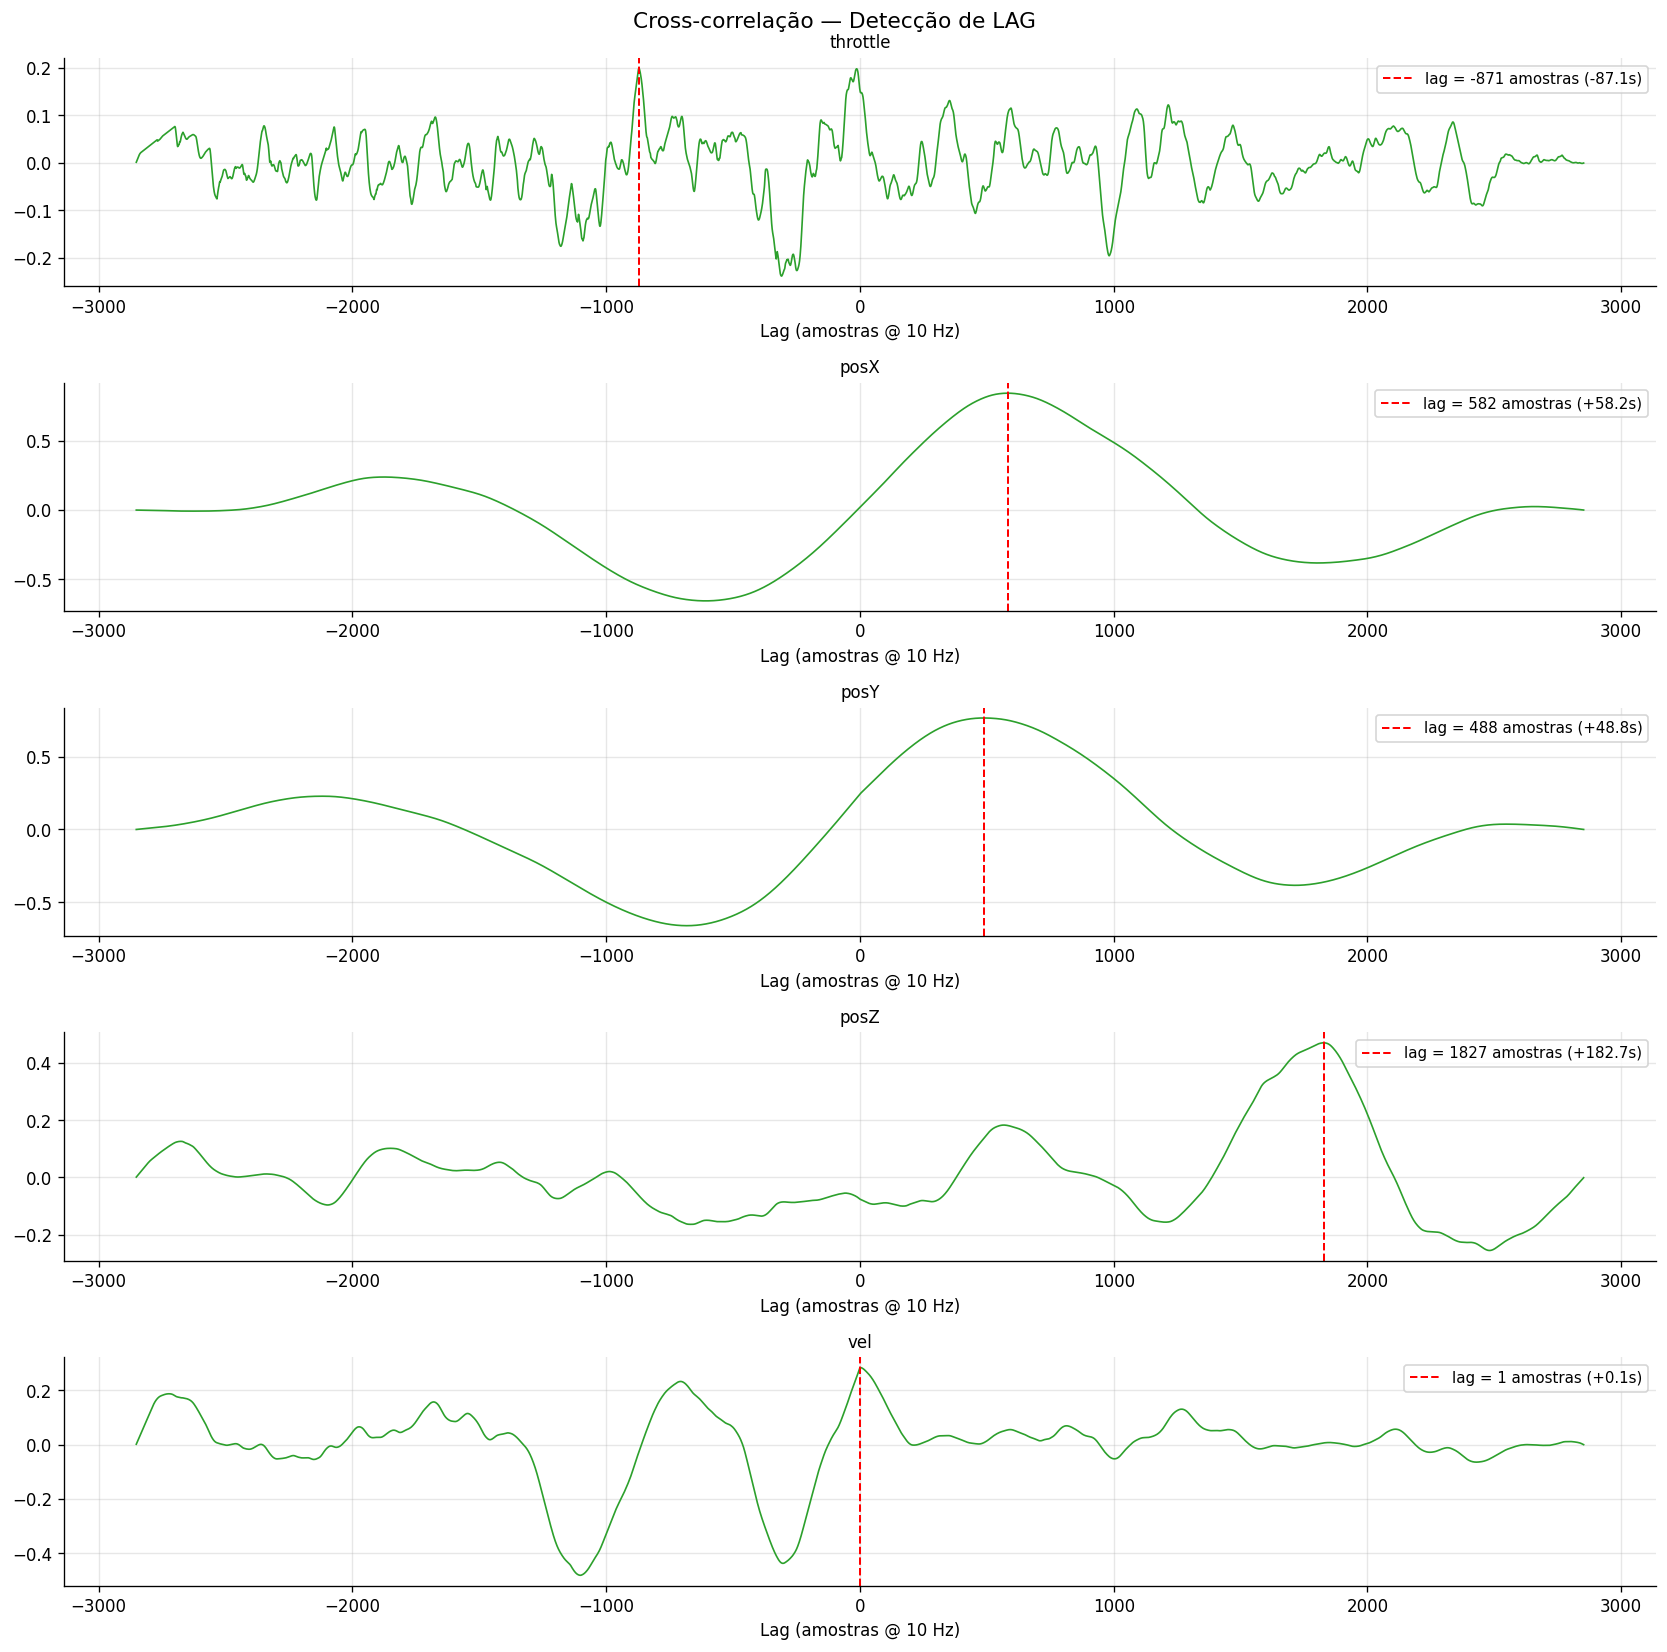


Lags detectados:
  throttle  : -871 amostras = -87.1s
  posX      : +582 amostras = +58.2s
  posY      : +488 amostras = +48.8s
  posZ      : +1827 amostras = +182.7s
  vel       : +1 amostras = +0.1s


In [21]:
lags = {}

fig, axes = plt.subplots(len(colunas), 1, figsize=(14, 2.8 * len(colunas)))
if len(colunas) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas):
    x = df[f'real_{col}'].values
    y = df[f'sim_{col}'].values

    corr      = correlate(x - x.mean(), y - y.mean(), mode='full')
    norm_denom = np.std(x) * np.std(y) * len(x)
    corr      = corr / norm_denom if norm_denom > 0 else corr

    lag_range = np.arange(-(len(x) - 1), len(x))
    lag_opt   = int(lag_range[np.argmax(corr)])
    lags[col] = lag_opt

    ax.plot(lag_range, corr, lw=1, color='#2ca02c')
    ax.axvline(lag_opt, color='red', ls='--', lw=1.2,
               label=f'lag = {lag_opt} amostras ({lag_opt * 0.1:+.1f}s)')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlabel('Lag (amostras @ 10 Hz)')

fig.suptitle('Cross-correlação — Detecção de LAG', fontsize=13)
plt.tight_layout()
plt.show()

print("\nLags detectados:")
for col, lag in lags.items():
    print(f"  {col:10s}: {lag:+d} amostras = {lag * 0.1:+.1f}s")

In [22]:
# Aplicar shift
for col, lag in lags.items():
    df[f'sim_{col}_shifted'] = df[f'sim_{col}'].shift(lag)

df = df.dropna()
print(f"Shape após shift: {df.shape}")

Shape após shift: (155, 15)


## 12. Correlação de Pearson global

In [23]:
resultados_pearson = {}

print(f"{'Coluna':<12} {'r (sem lag)':>12} {'p-value':>12} {'r (com lag)':>12} {'p-value':>12}")
print("-" * 65)

for col in colunas:
    x  = df[f'real_{col}'].values
    y  = df[f'sim_{col}'].values
    ys = df[f'sim_{col}_shifted'].values

    r_raw,   p_raw   = pearsonr(x, y)
    r_shift, p_shift = pearsonr(x, ys)

    resultados_pearson[col] = dict(r_raw=r_raw, p_raw=p_raw, r_shift=r_shift, p_shift=p_shift)
    print(f"{col:<12} {r_raw:>12.4f} {p_raw:>12.2e} {r_shift:>12.4f} {p_shift:>12.2e}")

Coluna        r (sem lag)      p-value  r (com lag)      p-value
-----------------------------------------------------------------
throttle          -0.2656     8.36e-04       0.0564     4.86e-01
posX               0.9733     1.19e-99       0.9831    1.13e-114
posY              -0.4938     6.64e-11       0.8654     9.00e-48
posZ              -0.3126     7.50e-05       0.1599     4.69e-02
vel                0.4543     2.88e-09       0.4267     3.09e-08


## 13. Pearson com Janela Deslizante

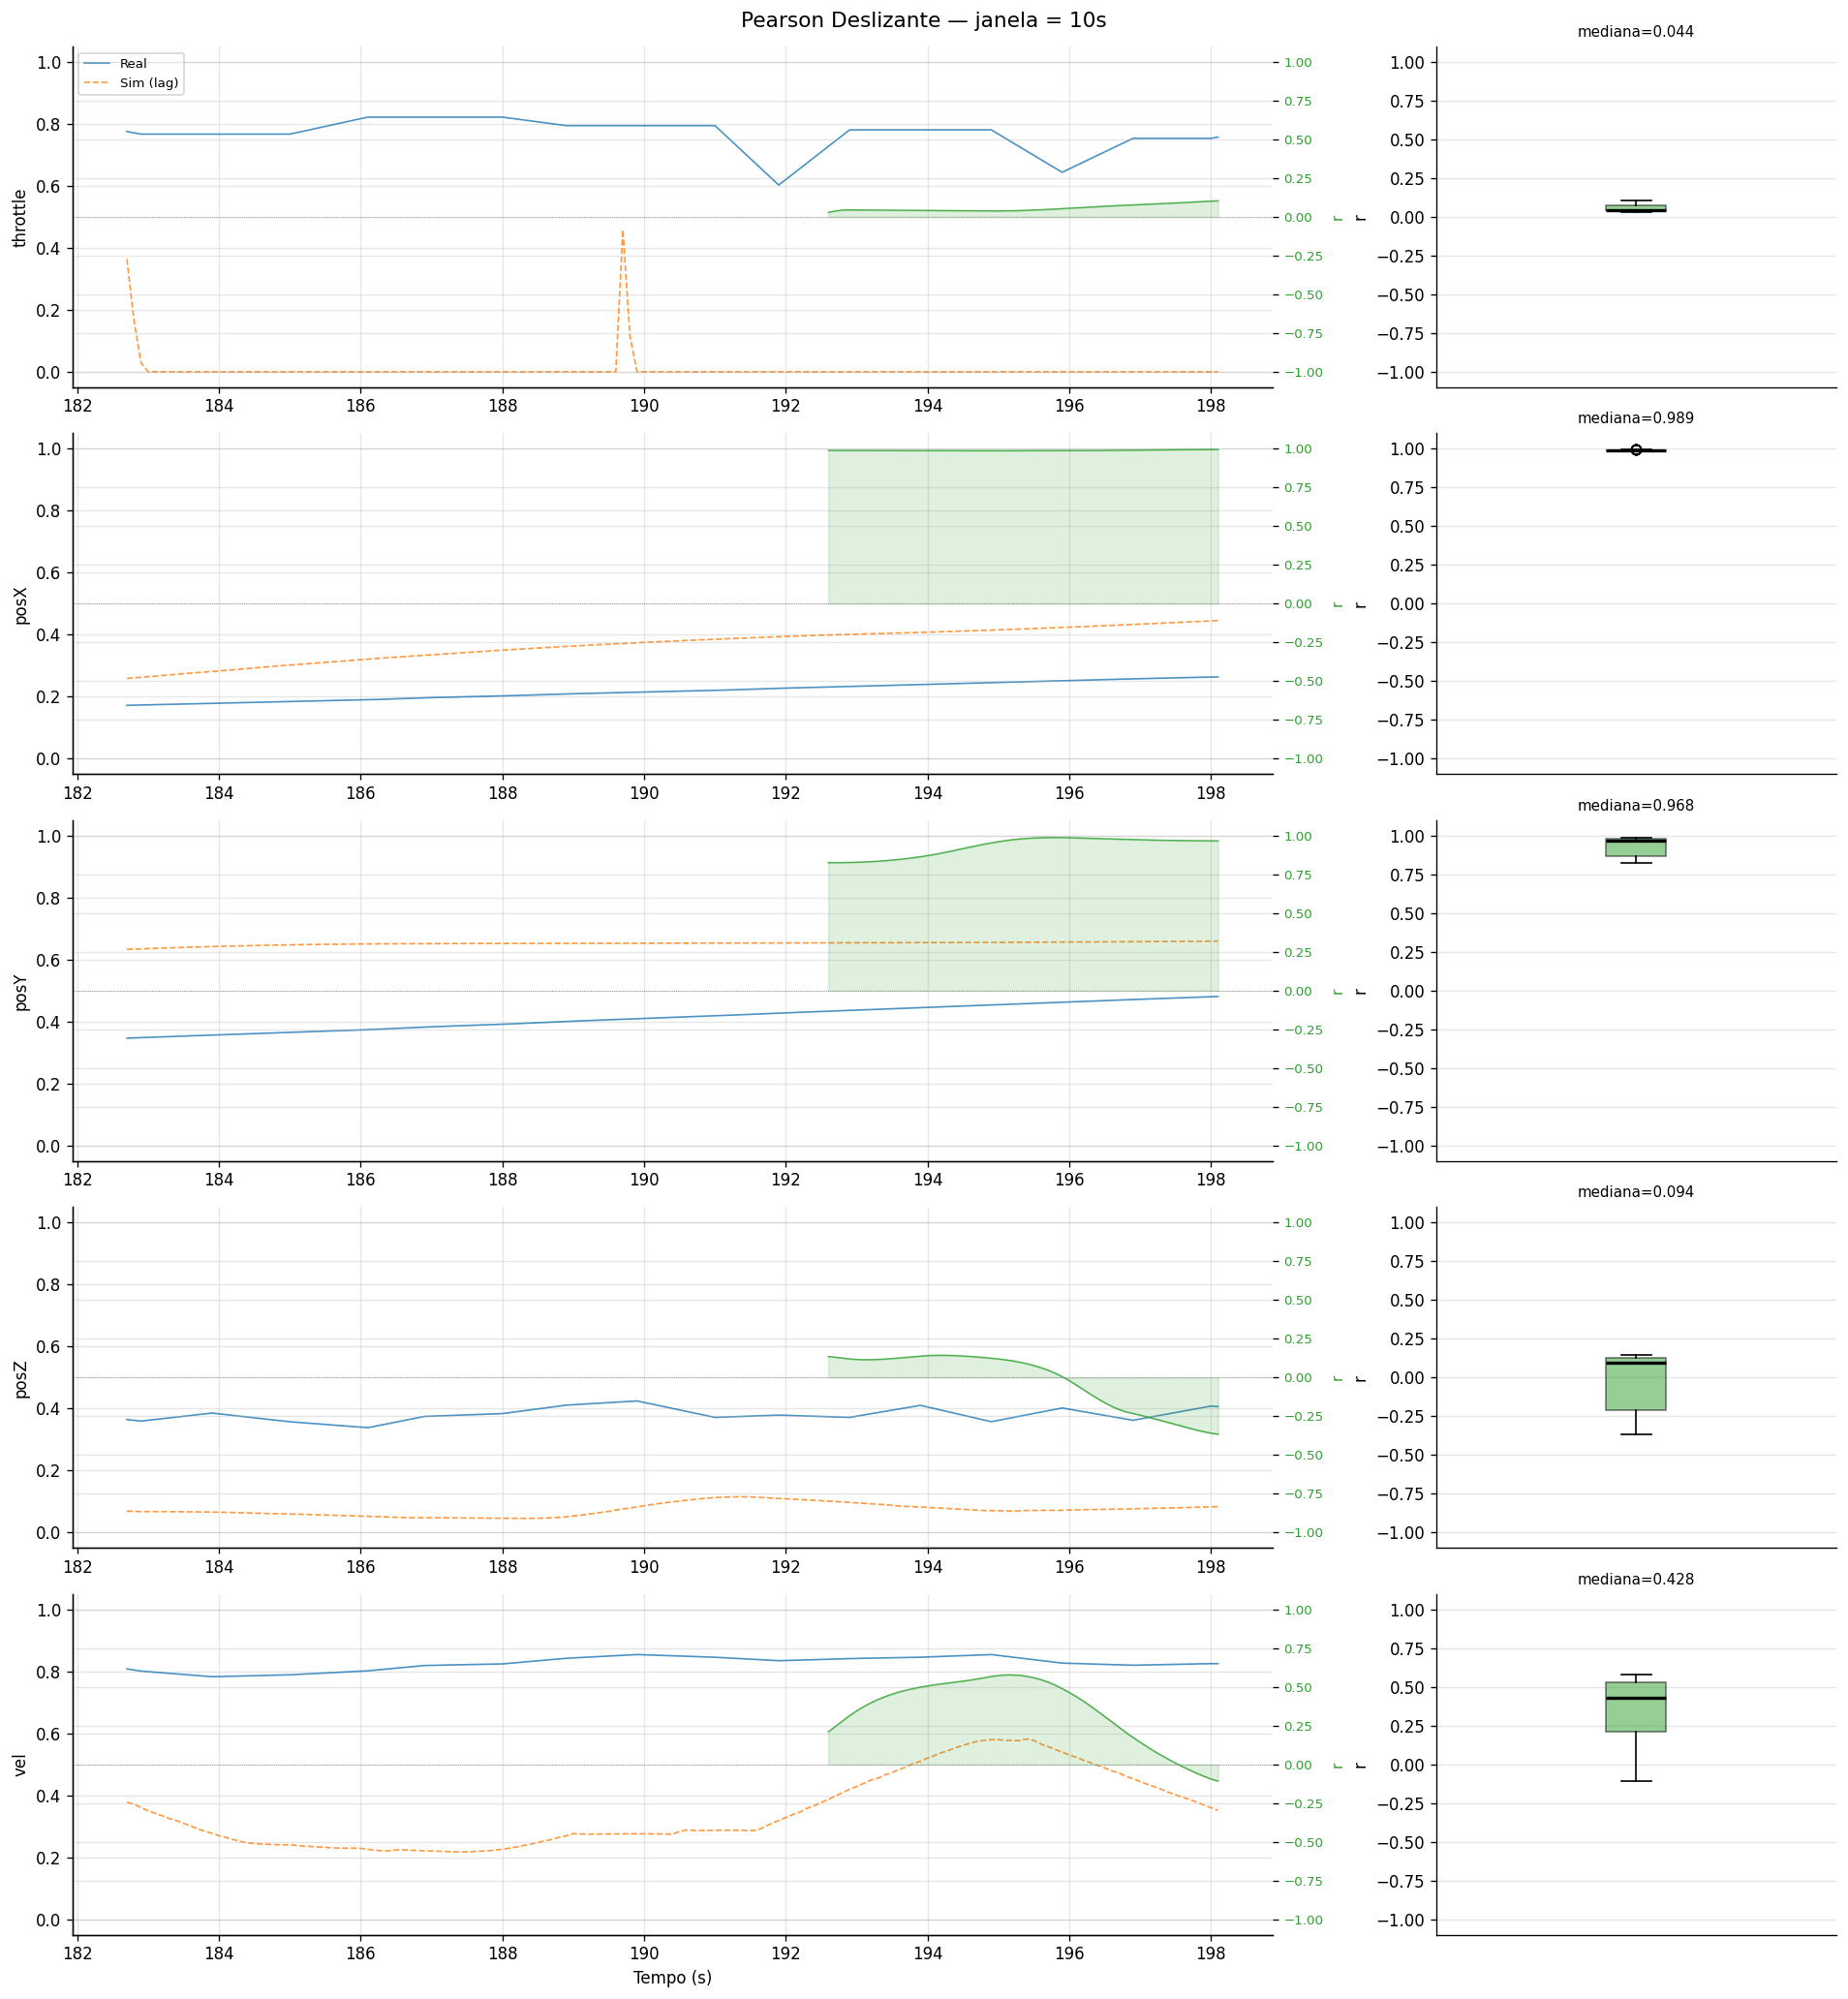

In [24]:
def pearson_sliding_window(x, y, janela=50):
    """Pearson vetorizado com stride_tricks. Retorna array de r com NaN no início."""
    n = len(x)
    r = np.full(n, np.nan)

    shape   = (n - janela + 1, janela)
    strides = (x.strides[0], x.strides[0])
    X = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
    Y = np.lib.stride_tricks.as_strided(y, shape=shape, strides=strides)

    Xm = X - X.mean(axis=1, keepdims=True)
    Ym = Y - Y.mean(axis=1, keepdims=True)
    num   = (Xm * Ym).sum(axis=1)
    denom = np.sqrt((Xm**2).sum(axis=1) * (Ym**2).sum(axis=1))

    with np.errstate(invalid='ignore'):
        r[janela - 1:] = np.where(denom > 1e-10, num / denom, np.nan)
    return r


JANELA_S   = 10
FREQ_HZ    = 10
janela_pts = JANELA_S * FREQ_HZ

t = df.index.total_seconds().values

fig, axes = plt.subplots(
    len(colunas), 2, figsize=(16, 3.5 * len(colunas)),
    gridspec_kw={'width_ratios': [3, 1]}
)
if len(colunas) == 1:
    axes = [axes]

for i, col in enumerate(colunas):
    x  = df[f'real_{col}'].values
    ys = df[f'sim_{col}_shifted'].values
    r_slide = pearson_sliding_window(x, ys, janela=janela_pts)

    ax_ts  = axes[i][0]
    ax_box = axes[i][1]

    ax_ts.plot(t, x,  label='Real',      color='#1f77b4', lw=1.0, alpha=0.8)
    ax_ts.plot(t, ys, label='Sim (lag)', color='#ff7f0e', lw=1.0, alpha=0.8, ls='--')

    ax2 = ax_ts.twinx()
    ax2.fill_between(t, r_slide, alpha=0.15, color='#2ca02c', where=~np.isnan(r_slide))
    ax2.plot(t, r_slide, color='#2ca02c', lw=0.9, alpha=0.8)
    ax2.set_ylim(-1.1, 1.1)
    ax2.set_ylabel('r', color='#2ca02c', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='#2ca02c', labelsize=8)
    ax2.axhline(0, color='gray', lw=0.5, ls=':')

    ax_ts.set_ylabel(col, fontsize=10)
    ax_ts.set_ylim(-0.05, 1.05)
    if i == 0:
        ax_ts.legend(loc='upper left', fontsize=8)
    if i == len(colunas) - 1:
        ax_ts.set_xlabel('Tempo (s)')

    r_valid = r_slide[~np.isnan(r_slide)]
    ax_box.boxplot(r_valid, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#2ca02c', alpha=0.5),
                   medianprops=dict(color='black', lw=2))
    ax_box.set_ylim(-1.1, 1.1)
    ax_box.set_ylabel('r')
    ax_box.set_xticks([])
    ax_box.set_title(f'mediana={np.median(r_valid):.3f}', fontsize=9)

fig.suptitle(f'Pearson Deslizante — janela = {JANELA_S}s', fontsize=13)
plt.tight_layout()
plt.show()

## 14. Heatmap de Pearson por variável × tempo

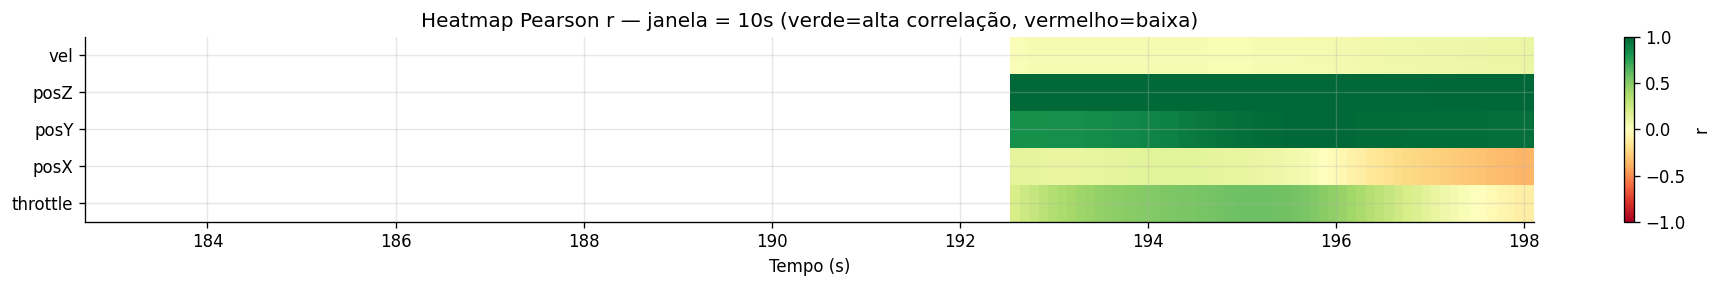

In [25]:
matriz_r = np.vstack([
    pearson_sliding_window(
        df[f'real_{col}'].values,
        df[f'sim_{col}_shifted'].values,
        janela=janela_pts
    )
    for col in colunas
])

fig, ax = plt.subplots(figsize=(16, 2.5))
im = ax.imshow(
    matriz_r, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1,
    extent=[t[0], t[-1], -0.5, len(colunas) - 0.5]
)
ax.set_yticks(range(len(colunas)))
ax.set_yticklabels(colunas)
ax.set_xlabel('Tempo (s)')
ax.set_title(f'Heatmap Pearson r — janela = {JANELA_S}s (verde=alta correlação, vermelho=baixa)')
plt.colorbar(im, ax=ax, label='r')
plt.tight_layout()
plt.show()

In [26]:
# Cálculo de Erro Físico (MAA - Mean Absolute Error)
print("\nERROS FÍSICOS MÉDIOS (Pós-alinhamento):")
for col in colunas:
    # Re-escalar de volta para unidades originais para o erro fazer sentido
    erro_abs = np.abs(real[col].values[:len(df)] - simulado[col].shift(lags[col]).values[:len(df)])
    unit = "m" if "pos" in col else "m/s" if "vel" in col else "%"
    print(f"  {col:10s}: {np.nanmean(erro_abs):.3f} {unit}")


ERROS FÍSICOS MÉDIOS (Pós-alinhamento):
  throttle  : 13.422 %
  posX      : nan m
  posY      : nan m
  posZ      : nan m
  vel       : 6.015 m/s


/tmp/ipykernel_378686/607930172.py:7: RuntimeWarning: Mean of empty slice
  print(f"  {col:10s}: {np.nanmean(erro_abs):.3f} {unit}")


In [27]:
dist_error = np.sqrt((df['real_posX'] - df['sim_posX_shifted'])**2 + 
                     (df['real_posY'] - df['sim_posY_shifted'])**2)
print(f"Erro Médio de Trajetória: {dist_error.mean():.2f} metros")

Erro Médio de Trajetória: 0.28 metros


In [28]:
# Testando diferentes curvas de resposta para o throttle simulado
def ajustar_throttle(df, gamma=1.0):
    # Aplica uma correção de potência: (x)^gamma
    return np.power(df['sim_throttle_shifted'], gamma)

# Exemplo: Se o simulado parece sempre mais alto que o real, tente gamma > 1
# Se o simulado parece "preguiçoso", tente gamma < 1
gamma_test = 1.2  # Ajuste este valor (ex: 0.8, 1.2, 1.5)
df['sim_throttle_corrected'] = ajustar_throttle(df, gamma=gamma_test)

from sklearn.metrics import mean_absolute_error
erro_antes = mean_absolute_error(df['real_throttle'], df['sim_throttle_shifted'])
erro_depois = mean_absolute_error(df['real_throttle'], df['sim_throttle_corrected'])

print(f"Erro Throttle Original: {erro_antes:.2%}")
print(f"Erro Throttle Corrigido (gamma={gamma_test}): {erro_depois:.2%}")

Erro Throttle Original: 75.86%
Erro Throttle Corrigido (gamma=1.2): 76.01%


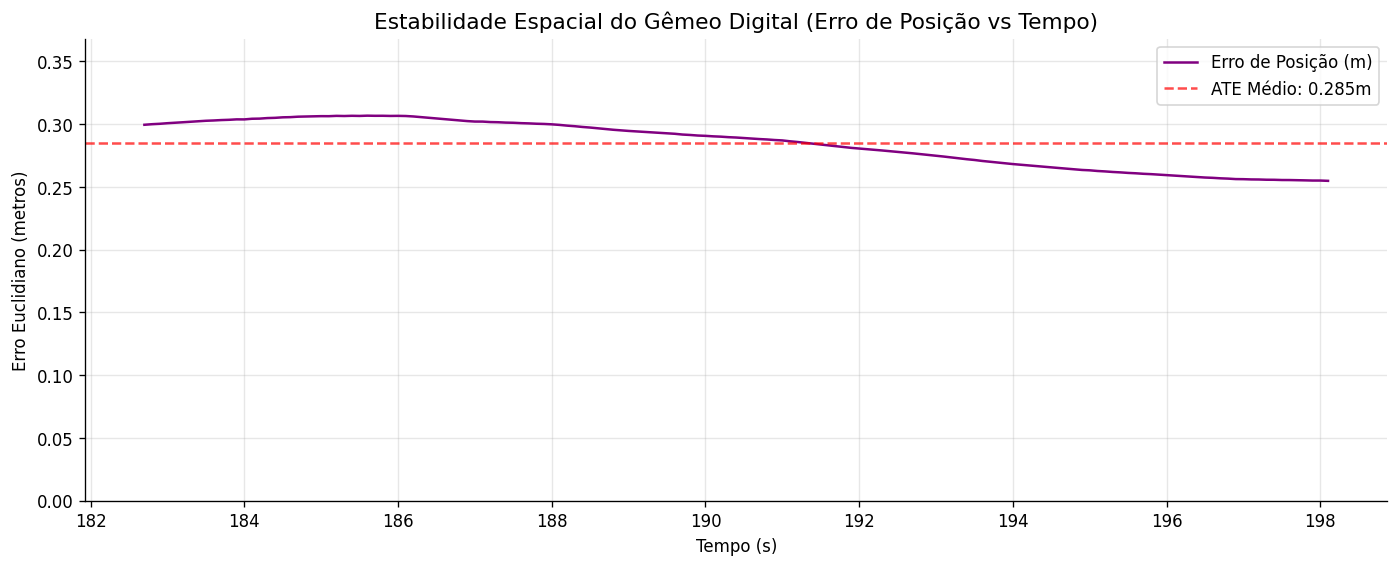

In [29]:
# Cálculo do erro euclidiano ponto a ponto (distância real no plano XY)
df['erro_distancia'] = np.sqrt(
    (df['real_posX'] - df['sim_posX_shifted'])**2 + 
    (df['real_posY'] - df['sim_posY_shifted'])**2
)

plt.figure(figsize=(14, 5))
plt.plot(df.index.total_seconds(), df['erro_distancia'], color='purple', lw=1.5, label='Erro de Posição (m)')

# Linha de média
ate_medio = df['erro_distancia'].mean()
plt.axhline(ate_medio, color='red', linestyle='--', alpha=0.7, label=f'ATE Médio: {ate_medio:.3f}m')

plt.title('Estabilidade Espacial do Gêmeo Digital (Erro de Posição vs Tempo)', fontsize=13)
plt.xlabel('Tempo (s)')
plt.ylabel('Erro Euclidiano (metros)')
plt.ylim(0, max(df['erro_distancia']) * 1.2) # Foco no zero
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
print(f"Máximo Real: {df['real_throttle'].max()}")
print(f"Máximo Simulado: {df['sim_throttle_shifted'].max()}")

Máximo Real: 0.8219178096547196
Máximo Simulado: 0.45827894181426027


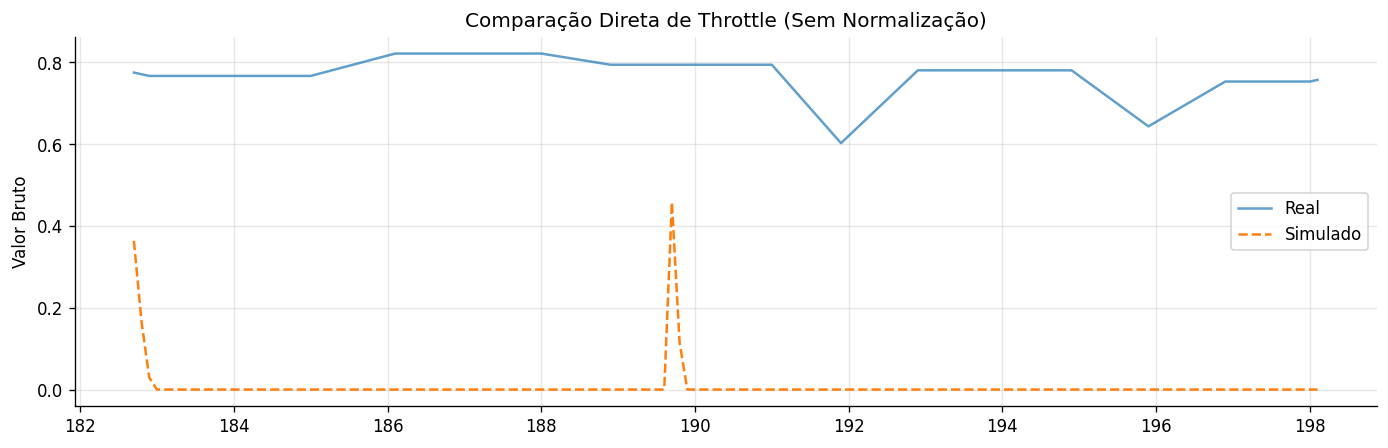

In [31]:
plt.figure(figsize=(14, 4))
plt.plot(df.index.total_seconds(), df['real_throttle'], label='Real', alpha=0.7)
plt.plot(df.index.total_seconds(), df['sim_throttle_shifted'], label='Simulado', ls='--')
plt.title('Comparação Direta de Throttle (Sem Normalização)')
plt.ylabel('Valor Bruto')
plt.legend()
plt.show()

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Garante que ambos falem a mesma língua (0 a 1)
df['real_throttle_norm'] = scaler.fit_transform(df[['real_throttle']])
df['sim_throttle_norm'] = scaler.fit_transform(df[['sim_throttle_shifted']])

erro_norm = mean_absolute_error(df['real_throttle_norm'], df['sim_throttle_norm'])
print(f"Erro Throttle Normalizado: {erro_norm:.2%}")

Erro Throttle Normalizado: 73.00%


In [33]:
from scipy.stats import linregress

# Calcula a relação: Real = slope * Simulado + intercept
slope, intercept, r_value, p_value, std_err = linregress(df['sim_throttle_shifted'], df['real_throttle'])

df['sim_throttle_mapped'] = df['sim_throttle_shifted'] * slope + intercept

erro_final = np.abs(df['real_throttle'] - df['sim_throttle_mapped']).mean()
print(f"Novo Erro Throttle (Mapeado): {erro_final:.4f}")
print(f"R^2 (Correlação): {r_value**2:.4f}")

Novo Erro Throttle (Mapeado): 0.0353
R^2 (Correlação): 0.0032


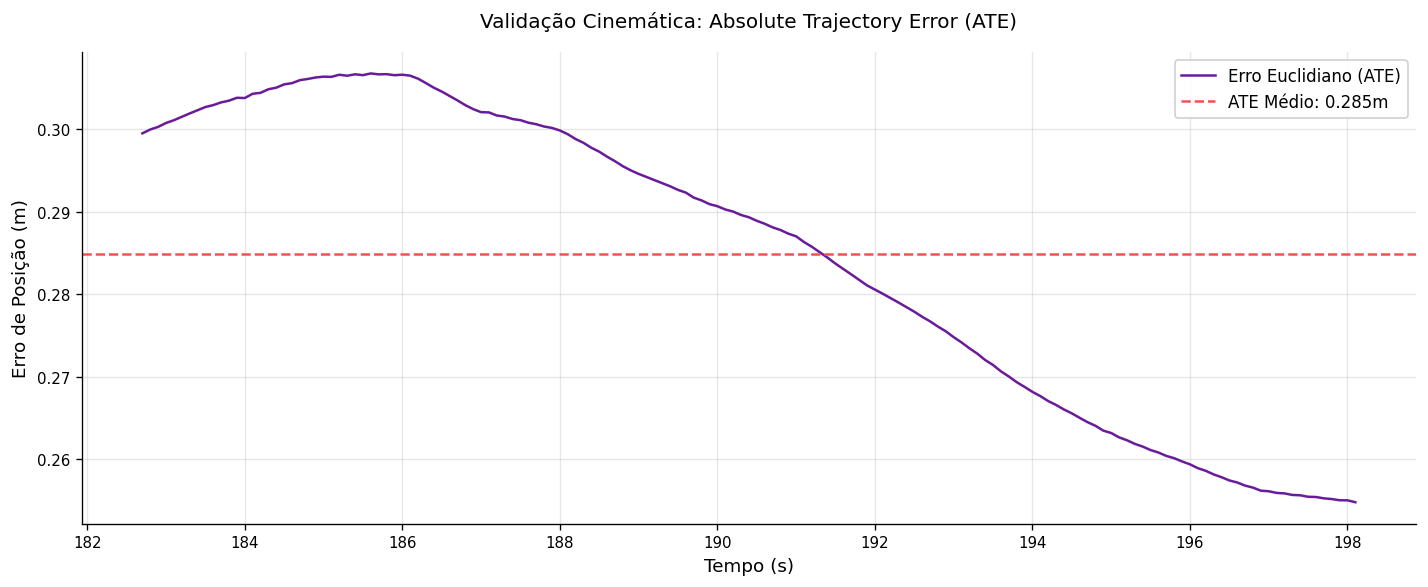

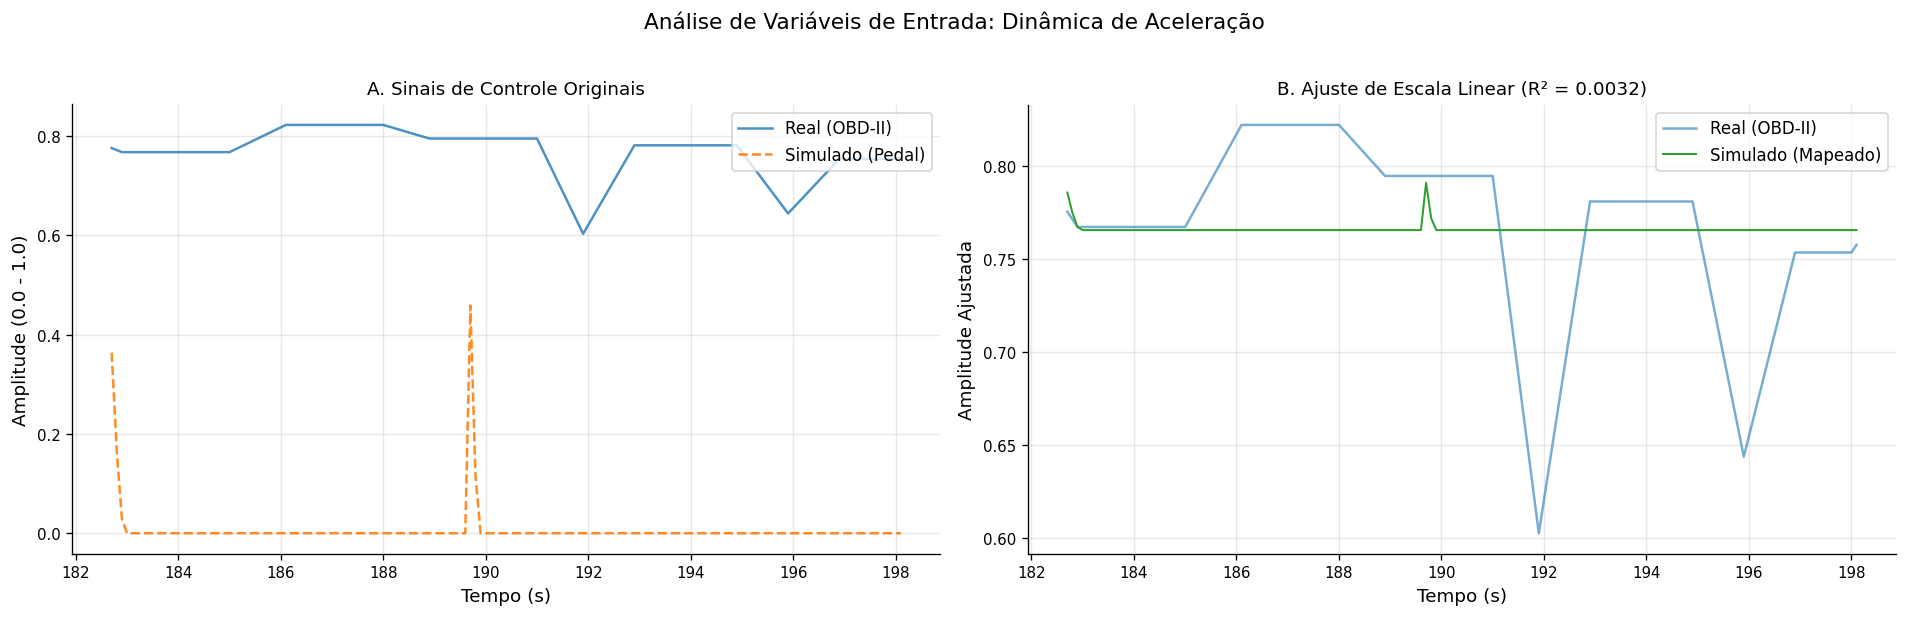

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Configurações estéticas para publicação (IEEE/ACM style)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Gráfico de Estabilidade Espacial (ATE)
def plot_ate(df):
    t = df.index.total_seconds()
    ate_medio = df['erro_distancia'].mean()
    
    plt.figure(figsize=(12, 5))
    plt.plot(t, df['erro_distancia'], color='#6a1b9a', lw=1.5, label='Erro Euclidiano (ATE)')
    plt.axhline(ate_medio, color='#ef5350', linestyle='--', lw=1.5, 
                label=f'ATE Médio: {ate_medio:.3f}m')
    
    plt.title('Validação Cinemática: Absolute Trajectory Error (ATE)', pad=15)
    plt.xlabel('Tempo (s)')
    plt.ylabel('Erro de Posição (m)')
    plt.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

## 2. Gráfico Comparativo de Controle (Throttle)
def plot_throttle_comparison(df, r_squared):
    t = df.index.total_seconds()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    
    # Subplot A: Sinais Originais
    ax1.plot(t, df['real_throttle'], color='#1f77b4', alpha=0.8, label='Real (OBD-II)')
    ax1.plot(t, df['sim_throttle_shifted'], color='#ff7f0e', ls='--', alpha=0.9, label='Simulado (Pedal)')
    ax1.set_title('A. Sinais de Controle Originais', fontsize=11)
    ax1.set_ylabel('Amplitude (0.0 - 1.0)')
    ax1.set_xlabel('Tempo (s)')
    ax1.legend(loc='upper right')
    
    # Subplot B: Mapeamento Linear
    ax2.plot(t, df['real_throttle'], color='#1f77b4', alpha=0.6, label='Real (OBD-II)')
    ax2.plot(t, df['sim_throttle_mapped'], color='#2ca02c', ls='-', lw=1.2, label='Simulado (Mapeado)')
    ax2.set_title(f'B. Ajuste de Escala Linear (R² = {r_squared:.4f})', fontsize=11)
    ax2.set_ylabel('Amplitude Ajustada')
    ax2.set_xlabel('Tempo (s)')
    ax2.legend(loc='upper right')
    
    plt.suptitle('Análise de Variáveis de Entrada: Dinâmica de Aceleração', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# Chamada das funções (certifique-se de que o dataframe 'df' e o 'r_value' existem)
plot_ate(df)
plot_throttle_comparison(df, r_value**2)

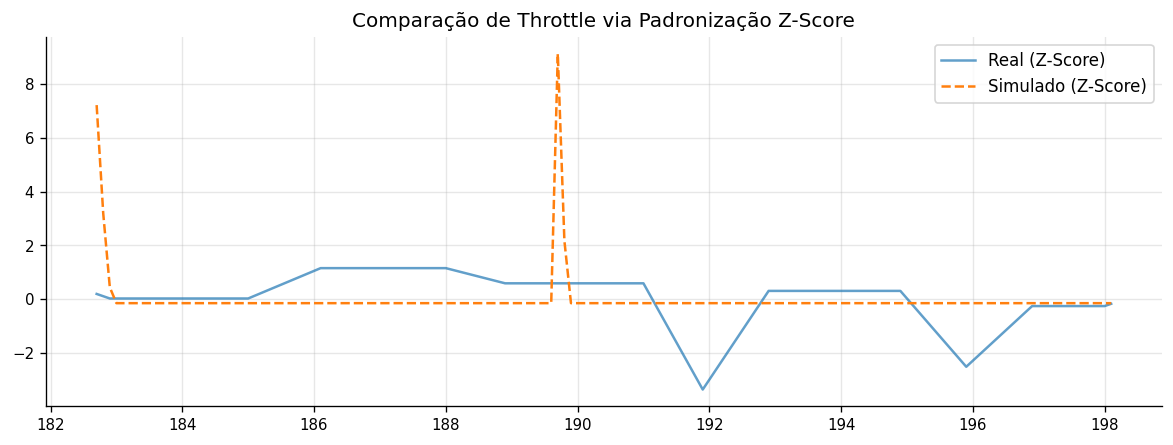

In [35]:
# Padronização (Média 0, Desvio Padrão 1)
df['real_throttle_z'] = (df['real_throttle'] - df['real_throttle'].mean()) / df['real_throttle'].std()
df['sim_throttle_z'] = (df['sim_throttle_shifted'] - df['sim_throttle_shifted'].mean()) / df['sim_throttle_shifted'].std()

plt.figure(figsize=(12, 4))
plt.plot(df.index.total_seconds(), df['real_throttle_z'], label='Real (Z-Score)', alpha=0.7)
plt.plot(df.index.total_seconds(), df['sim_throttle_z'], label='Simulado (Z-Score)', ls='--')
plt.title('Comparação de Throttle via Padronização Z-Score')
plt.legend()
plt.show()

In [36]:
# Suavizando o simulador com uma janela de 1 segundo (10 amostras)
df['sim_throttle_smooth'] = df['sim_throttle_shifted'].rolling(window=10).mean()

# Tente a regressão novamente com o sinal suavizado
from scipy.stats import linregress
mask = ~df['sim_throttle_smooth'].isna()
slope, intercept, r_val, p_val, std_err = linregress(
    df.loc[mask, 'sim_throttle_smooth'], 
    df.loc[mask, 'real_throttle']
)

print(f"Novo R² após suavização: {r_val**2:.4f}")

Novo R² após suavização: 0.0235


## 15. Resumo final

In [37]:
print("=" * 60)
print("RESUMO — REAL × SIMULADO BeamNG Digital Twin")
print("=" * 60)
print(f"{'Variável':<10} {'r_global':>9} {'r_mediana':>10} {'lag (s)':>9}")
print("-" * 45)

for col in colunas:
    r_global = resultados_pearson[col]['r_shift']
    r_slide  = pearson_sliding_window(
        df[f'real_{col}'].values,
        df[f'sim_{col}_shifted'].values,
        janela=janela_pts
    )
    r_med = np.nanmedian(r_slide)
    lag_s = lags[col] * 0.1
    print(f"{col:<10} {r_global:>9.4f} {r_med:>10.4f} {lag_s:>+9.1f}s")

print("=" * 60)

RESUMO — REAL × SIMULADO BeamNG Digital Twin
Variável    r_global  r_mediana   lag (s)
---------------------------------------------
throttle      0.0564     0.0443     -87.1s
posX          0.9831     0.9893     +58.2s
posY          0.8654     0.9677     +48.8s
posZ          0.1599     0.0941    +182.7s
vel           0.4267     0.4281      +0.1s


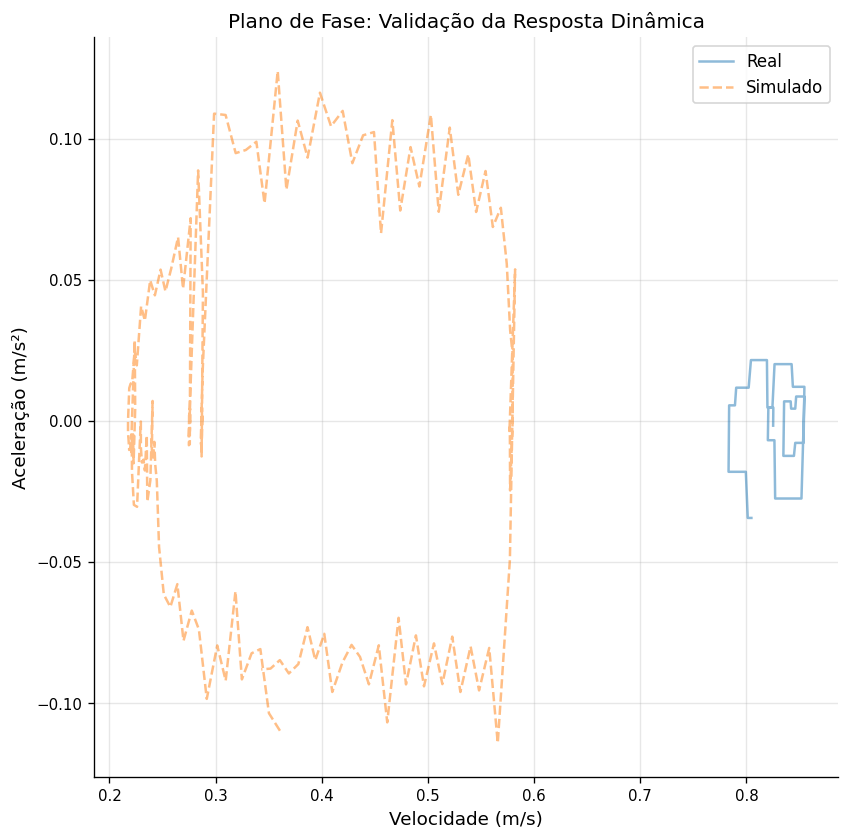

In [38]:
# Cálculo da aceleração (derivada da velocidade)
df['real_accel'] = df['real_vel'].diff() / 0.1
df['sim_accel'] = df['sim_vel'].diff() / 0.1

plt.figure(figsize=(8, 8))
plt.plot(df['real_vel'], df['real_accel'], label='Real', alpha=0.5)
plt.plot(df['sim_vel'], df['sim_accel'], label='Simulado', alpha=0.5, ls='--')
plt.xlabel('Velocidade (m/s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Plano de Fase: Validação da Resposta Dinâmica')
plt.legend()
plt.show()

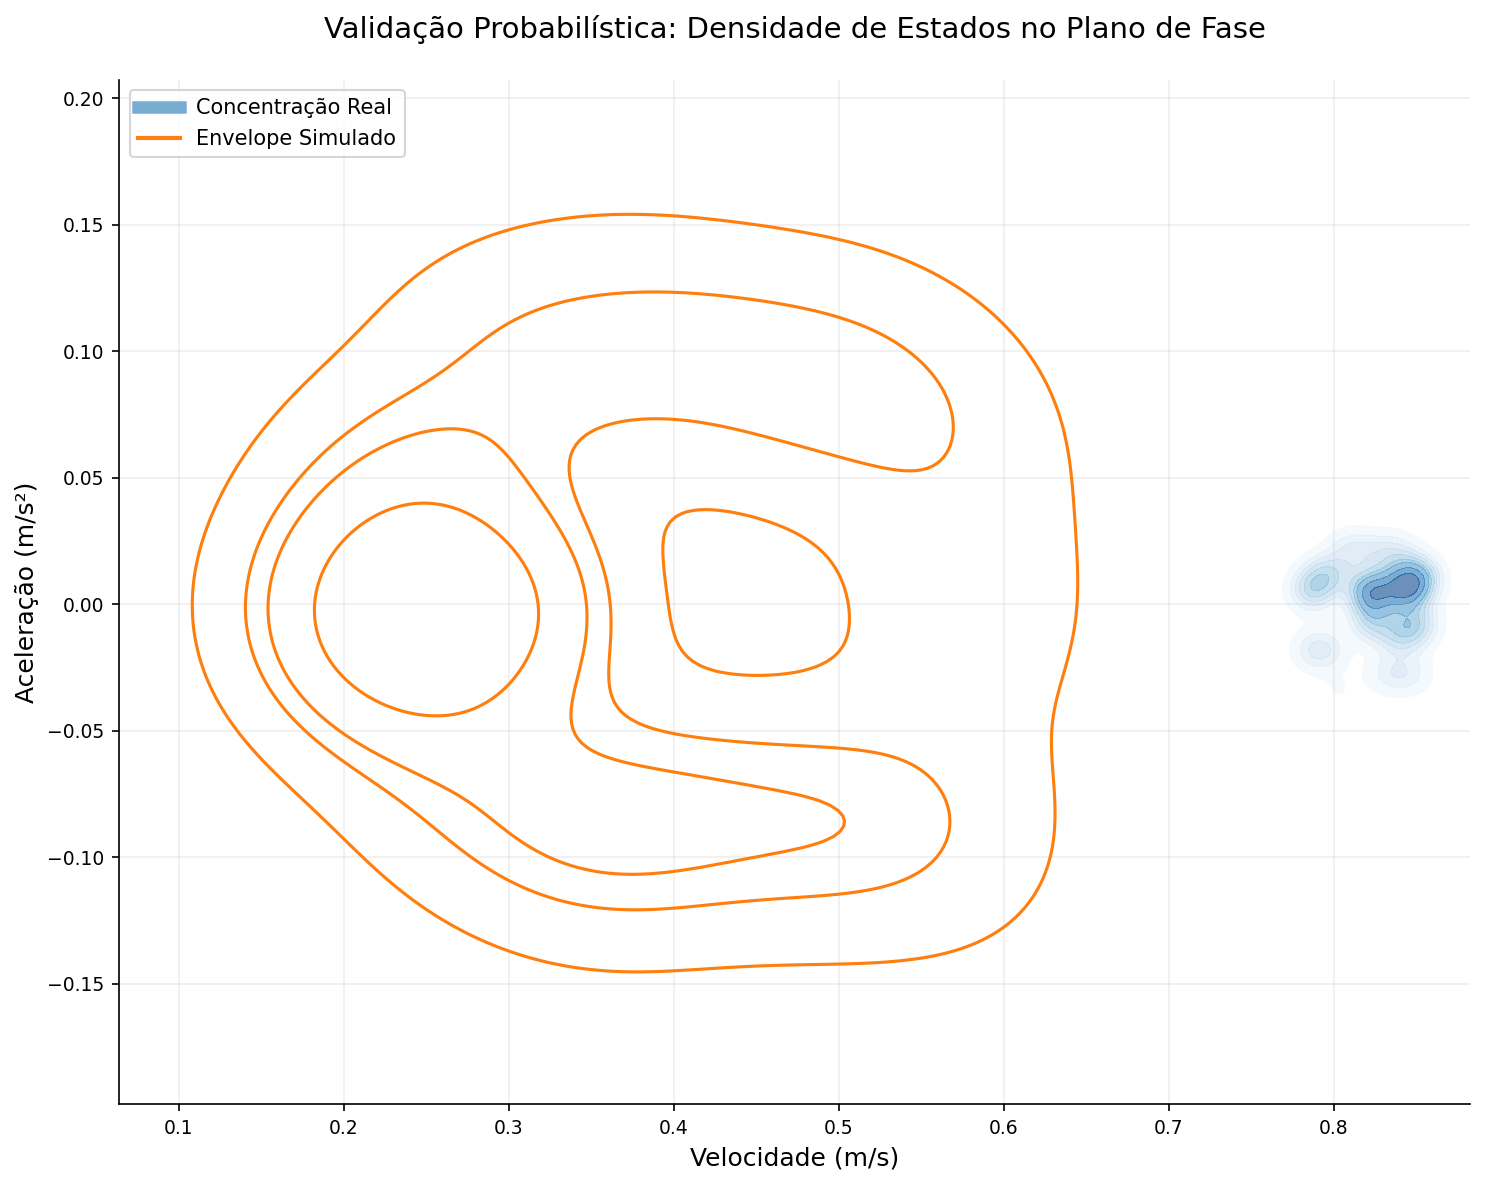

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_kde_validacao(df):
    """
    Gera o gráfico de densidade (KDE) para o Plano de Fase.
    Requer as colunas: 'real_vel', 'real_accel', 'sim_vel_shifted' e 'sim_accel'.
    """
    
    # Configurações de estilo para publicação
    plt.rcParams.update({
        'figure.dpi': 150,
        'font.size': 10,
        'axes.grid': True,
        'grid.alpha': 0.2
    })

    plt.figure(figsize=(10, 8))

    # 1. Camada de Densidade Real (Preenchida/Heatmap)
    sns.kdeplot(
        x=df['real_vel'], 
        y=df['real_accel'], 
        fill=True, 
        cmap="Blues", 
        alpha=0.6, 
        thresh=0.05, 
        label='Concentração Real'
    )

    # 2. Camada do Envelope Simulado (Apenas contornos)
    sns.kdeplot(
        x=df['sim_vel_shifted'], 
        y=df['sim_accel'], 
        fill=False, 
        color="#ff7f0e", 
        levels=5, 
        linewidths=1.5, 
        label='Envelope Simulado'
    )

    # Títulos e Eixos
    plt.title('Validação Probabilística: Densidade de Estados no Plano de Fase', pad=20, fontsize=14)
    plt.xlabel('Velocidade (m/s)', fontsize=12)
    plt.ylabel('Aceleração (m/s²)', fontsize=12)
    
    # Legenda customizada para garantir que apareça corretamente
    legend_elements = [
        Line2D([0], [0], color='#1f77b4', lw=6, alpha=0.6, label='Concentração Real'),
        Line2D([0], [0], color='#ff7f0e', lw=2, label='Envelope Simulado')
    ]
    plt.legend(handles=legend_elements, loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

# Chamada da função
plot_kde_validacao(df)

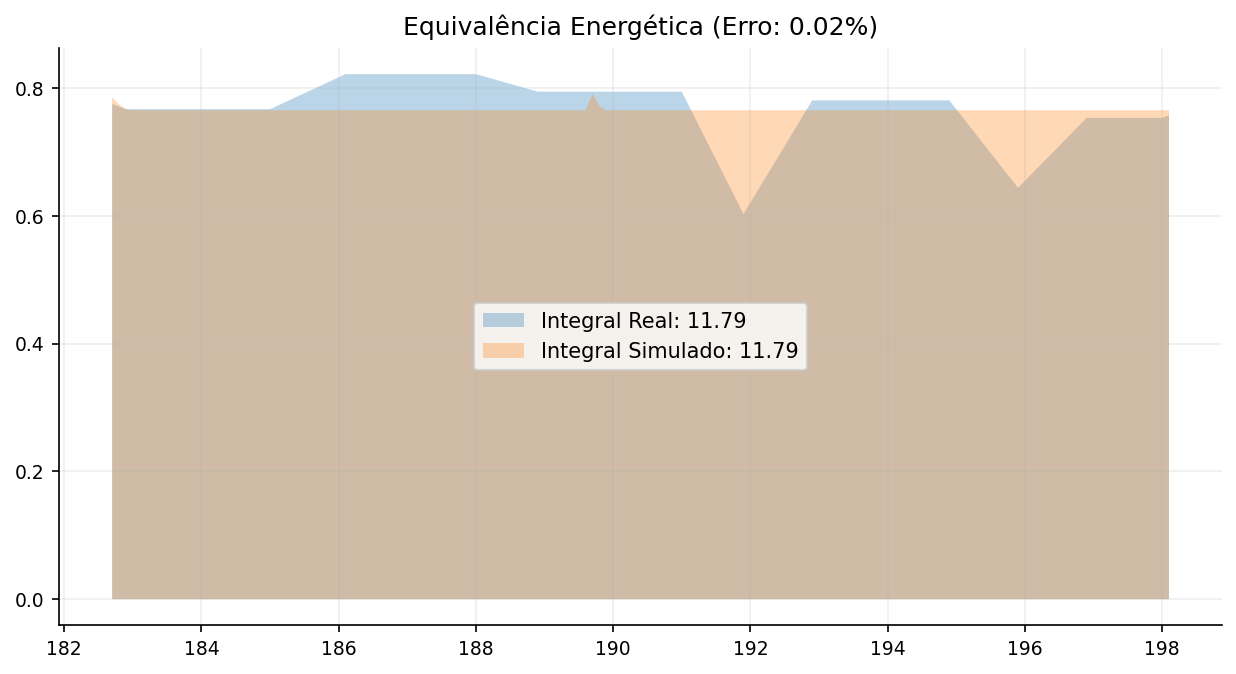

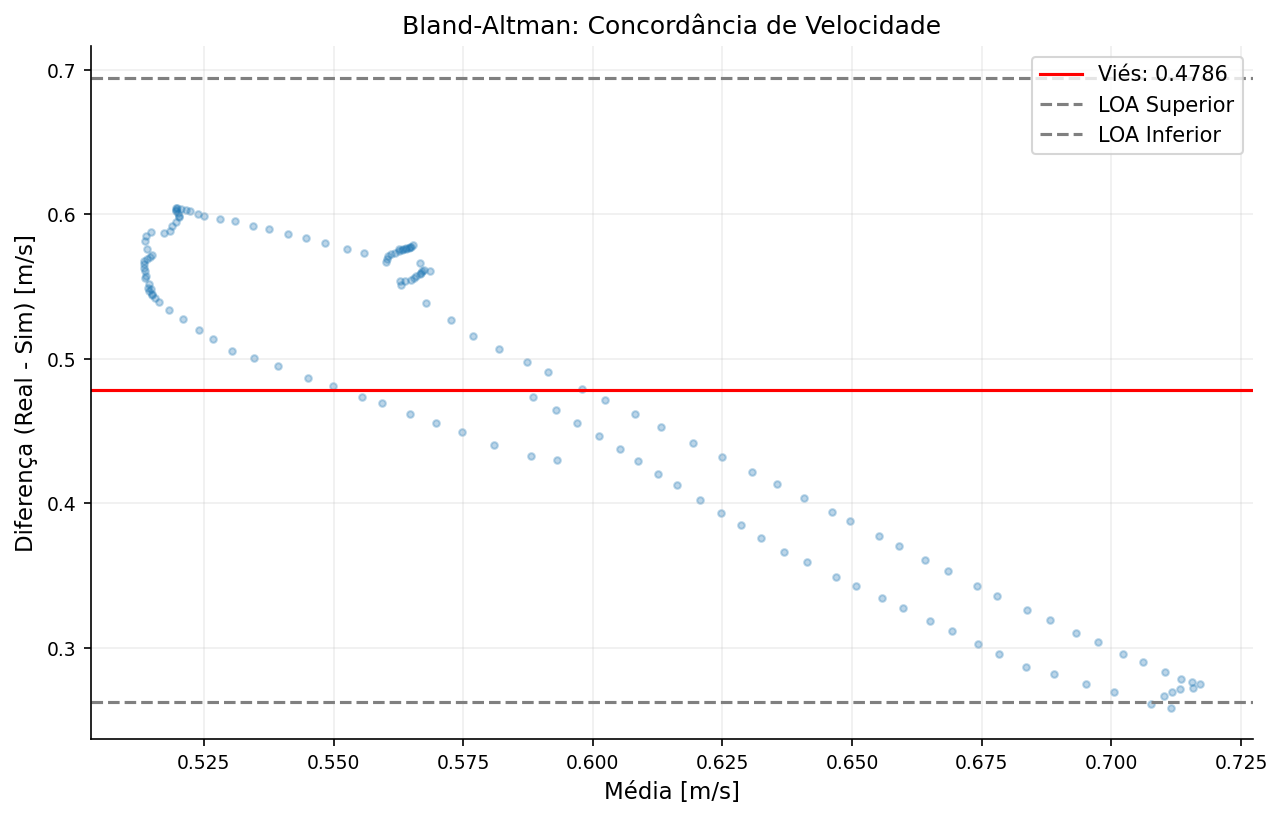

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# 1. Análise de Integral (Troque 'df' pelo seu dataframe)
t = df.index.total_seconds()
integral_real = simpson(df['real_throttle'], t)
integral_sim = simpson(df['sim_throttle_mapped'], t)
erro_int = abs(integral_real - integral_sim) / integral_real * 100

plt.figure(figsize=(10, 5))
plt.fill_between(t, df['real_throttle'], alpha=0.3, label=f'Integral Real: {integral_real:.2f}')
plt.fill_between(t, df['sim_throttle_mapped'], alpha=0.3, label=f'Integral Simulado: {integral_sim:.2f}')
plt.title(f'Equivalência Energética (Erro: {erro_int:.2f}%)')
plt.legend()
plt.show()

# 2. Bland-Altman
mean_v = (df['real_vel'] + df['sim_vel_shifted']) / 2
diff_v = df['real_vel'] - df['sim_vel_shifted']
md, sd = np.mean(diff_v), np.std(diff_v)

plt.figure(figsize=(10, 6))
plt.scatter(mean_v, diff_v, alpha=0.3, s=10)
plt.axhline(md, color='red', label=f'Viés: {md:.4f}')
plt.axhline(md + 1.96*sd, color='gray', ls='--', label='LOA Superior')
plt.axhline(md - 1.96*sd, color='gray', ls='--', label='LOA Inferior')
plt.title('Bland-Altman: Concordância de Velocidade')
plt.ylabel('Diferença (Real - Sim) [m/s]')
plt.xlabel('Média [m/s]')
plt.legend()
plt.show()